# Load Custom Datasets in PyTorch

In [39]:
import os
import requests
import random
from zipfile import ZipFile, BadZipFile
from typing import Tuple
from pathlib import Path

import numpy as np
import torch
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## System Config

In [5]:
def system_config(seed_value: int = 23) -> Tuple:
    """
    Configures the system environment for PyTorch-based operations.

    :param seed_value: Seed value for random number generation. Default is 42.
    :type seed_value: int

    :return: A tuple containing the device name as a string and a boolean indicating GPU availability.
    :rtype: tuple
    """

    random.seed(seed_value)
    np.random.seed(seed=seed_value)
    torch.manual_seed(seed=seed_value)

    if torch.cuda.is_available():
        print("Using GPU")

        torch.cuda.manual_seed(seed=seed_value)
        torch.cuda.manual_seed_all(seed=seed_value)

        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        return torch.device("cuda"), True

    torch.use_deterministic_algorithms(True)

    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print("Using Apple Silicon GPU")

        os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
        torch.mps.manual_seed(seed=seed_value)
        return torch.device("mps"), True

    print("Using CPU")
    return torch.device("cpu"), False

In [6]:
DEVICE, IS_GPU_AVAILABLE = system_config()

Using Apple Silicon GPU


## Download and Extract Dataset

In [10]:
ROOT = Path().resolve()
print(ROOT)

/Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/custom_datasets


In [11]:
def download_file(url: str, save_path: Path):
    response = requests.get(url=url, stream=True)
    with open(save_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file.write(chunk)

    print(f"Downloaded: {save_path}")


def unzip(zip_file_path: Path = None):
    try:
        with ZipFile(zip_file_path, "r") as z:
            z.extractall("./")
            print(f"Extracted {zip_file_path.name}")
    except FileNotFoundError:
        print("File not found")
    except BadZipFile:
        print("Invalid or corrupt zip file")
    except Exception as e:
        print(f"Error occured: {e}")

    return


url = r"https://www.dropbox.com/s/45jdd8padeyjq6t/10_Monkey_Species.zip?dl=1"
zipped_file_name = ROOT / "10_Monkey_Species.zip"
if not zipped_file_name.exists():
    download_file(url=url, save_path=zipped_file_name)
    unzip(zip_file_path=zipped_file_name)

Downloaded: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/custom_datasets/10_Monkey_Species.zip
Extracted 10_Monkey_Species.zip


## Explore Training Data

In [ ]:
training_data_root = ROOT / "data" / "training" / "training"

train_data = datasets.ImageFolder(root=training_data_root)

#### Dataset Classes

In [13]:
train_data.classes

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

#### Dataset Class to Index Mapping

In [14]:
train_data.class_to_idx

{'n0': 0,
 'n1': 1,
 'n2': 2,
 'n3': 3,
 'n4': 4,
 'n5': 5,
 'n6': 6,
 'n7': 7,
 'n8': 8,
 'n9': 9}

#### Data Length

In [16]:
len(train_data)

1097

#### Data Extensions

In [17]:
train_data.extensions

('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')

#### View Image and Target

In [19]:
def get_image_and_target_at_index(index: int):
    img, target = train_data[index]

    print("PIL image size: {}, target: {}".format(img.size, target))

    plt.imshow(img)
    plt.show()

PIL image size: (5184, 3456), target: 0


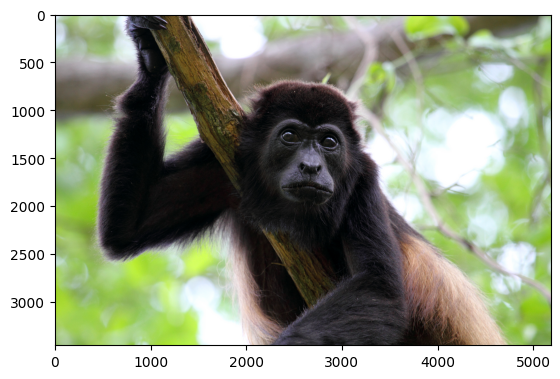

In [23]:
index1 = random.randint(a=0, b=len(train_data))
get_image_and_target_at_index(index=index1)

PIL image size: (866, 1299), target: 5


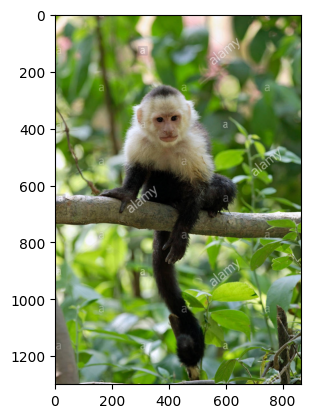

In [26]:
index2 = random.randint(a=0, b=len(train_data))
get_image_and_target_at_index(index=index2)

PIL image size: (426, 285), target: 7


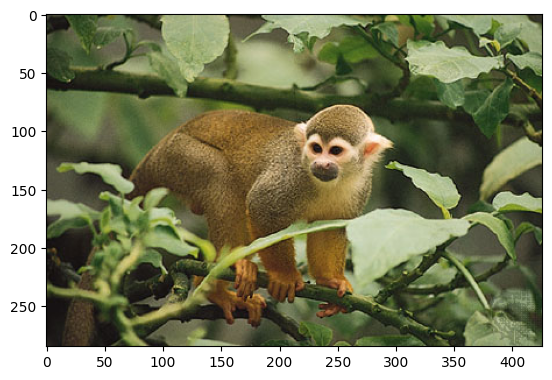

In [27]:
index3 = random.randint(a=0, b=len(train_data))
get_image_and_target_at_index(index=index3)

## Preprocess Dataset

### Transforms - Resize

In [29]:
train_data = datasets.ImageFolder(
    root=training_data_root, transform=transforms.Resize((224, 224))
)

PIL image size: (224, 224), target: 0


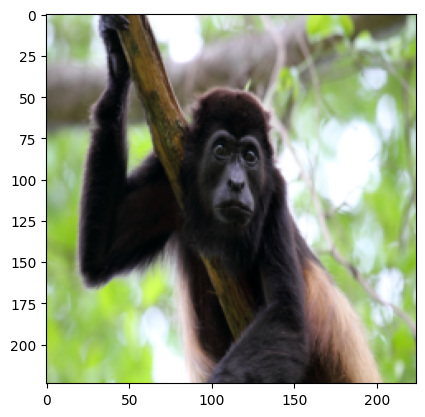

In [30]:
get_image_and_target_at_index(index=index1)

PIL image size: (224, 224), target: 5


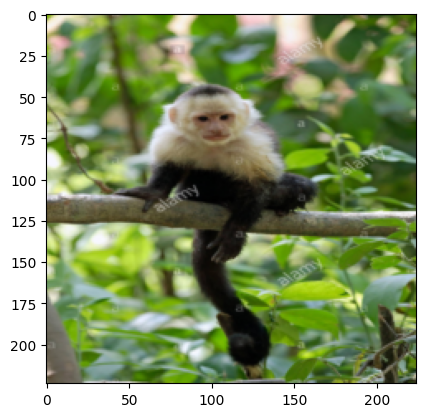

In [31]:
get_image_and_target_at_index(index=index2)

PIL image size: (224, 224), target: 7


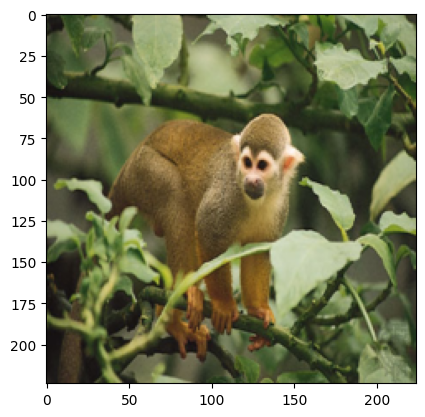

In [32]:
get_image_and_target_at_index(index=index3)

### Transforms - Resize - Maintain aspect ratio

In [33]:
train_data = datasets.ImageFolder(
    root=training_data_root, transform=transforms.Resize(224)
)

PIL image size: (336, 224), target: 0


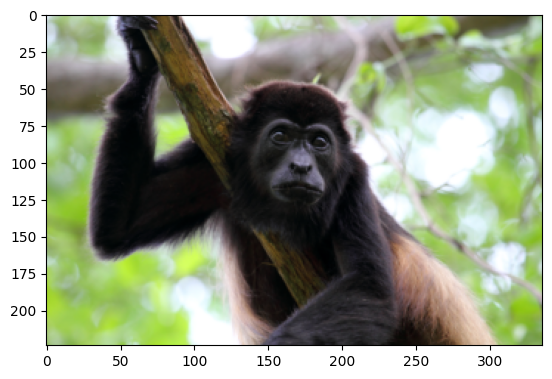

In [34]:
get_image_and_target_at_index(index=index1)

PIL image size: (224, 336), target: 5


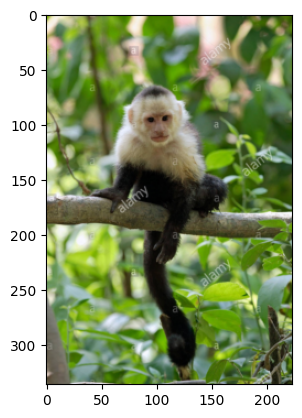

In [35]:
get_image_and_target_at_index(index=index2)

PIL image size: (334, 224), target: 7


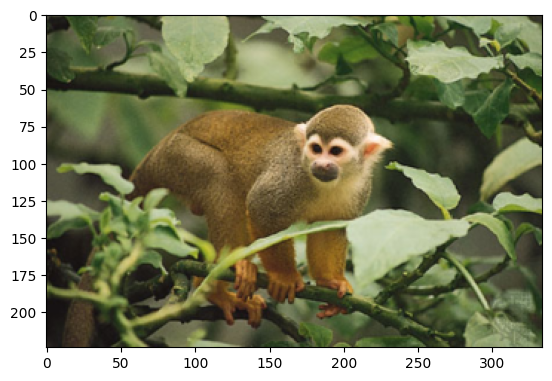

In [36]:
get_image_and_target_at_index(index=index3)

## DataLoader

In [ ]:
def get_data(batch_size: int, data_root: Path):
    preprocess = transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
        ]
    )

    train_dataloader = torch.utils.data.DataLoader(
        dataset=datasets.ImageFolder(
            root=data_root / "training" / "training", transform=preprocess
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    test_dataloader = torch.utils.data.DataLoader(
        dataset=datasets.ImageFolder(
            root=data_root / "validation" / "validation", transform=preprocess
        ),
        batch_size=batch_size,
        shuffle=False,
    )

    return train_dataloader, test_dataloader

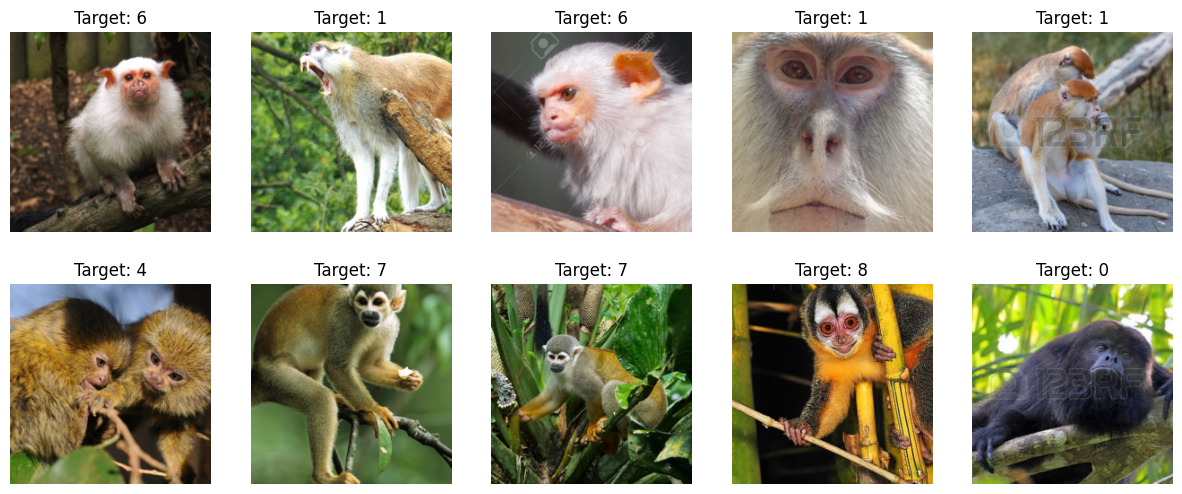

In [38]:
data_root = ROOT / "data"

train_loader, test_loader = get_data(batch_size=10, data_root=data_root)

plt.rcParams["figure.figsize"] = (15, 6)
plt.figure
for images, labels in train_loader:
    for i in range(len(labels)):
        plt.subplot(2, 5, i + 1)
        img = transforms.functional.to_pil_image(images[i])
        plt.imshow(img)
        plt.axis("off")
        plt.gca().set_title("Target: {0}".format(labels[i]))
    plt.show()
    break